# 🏭 Phase 3: Final Production Scaling Pipeline

This notebook is the **definitive, production-ready** scaling system.
It ties together every decision we made:

```
Raw Features
  ↓
STEP 1: Auto-select best transform per feature (Shapiro-Wilk driven)
  ↓
STEP 2: Apply only mathematical transforms (Log / Sqrt / CubeRoot)
     ← No Min-Max, No Z-Score here (they store training stats = risky)
  ↓
STEP 3: Z-Score on red-flag features ONLY → drop outliers (z > 3)
  ↓
STEP 4: Percentile Rank within surviving pool → all features in [0, 1]
  ↓
STEP 5: Shannon Entropy → dynamic weights (data decides importance)
  ↓
STEP 6: Weighted sum → Final Score (0–100)
```

### Why this design is correct
| Rule | Reason |
|------|--------|
| Log/Sqrt/CubeRoot for transforms | No fitting required. Safe on any new data. |
| Shapiro-Wilk picks the transform | Data tells us what it needs, not us guessing |
| Z-Score only for outlier removal | Single job: detect anomalies. Then discarded. |
| Percentile Rank for scoring | Bounded [0,1], unit-agnostic, robust to remaining outliers |
| Entropy for weights | High-variance features auto-weighted higher. No hardcoded numbers. |

---

## Cell 1: Imports and Configuration

In [11]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as scipy_stats
from scipy.stats import shapiro, boxcox, entropy, zscore
import warnings
warnings.filterwarnings('ignore')

# ── Skill Lists ─────────────────────────────────────────────────────────
CORE_SKILLS  = ["Python", "PyTorch", "Transformers", "NLP", "Machine Learning",
         "TensorFlow", "Deep Learning"]
STRONG_SKILLS = ["RAG", "Fine-tuning LLMs", "LangChain", "Vector Databases",
         "Milvus", "Computer Vision", "LoRA", "Weights & Biases",
         "Hugging Face", "MLOps"]
NICE_SKILLS  = ["Docker", "Kubernetes", "AWS", "GCP", "SQL",
         "Data Pipelines", "Spark", "Airflow"]
PROF_MULT   = {"expert": 1.2, "advanced": 1.0, "intermediate": 0.6, "beginner": 0.2}

# ── Pipeline Config ──────────────────────────────────────────────────────
# Change DATA_FILE to 'candidates.jsonl' when running on the full 100K
DATA_FILE   = 'candidates.jsonl'
IS_JSONL    = DATA_FILE.endswith('.jsonl')  # auto-detects file format
REFERENCE_DATE = pd.Timestamp('2026-07-01')
Z_THRESHOLD  = 3.0  # Candidates beyond this on red-flag features are eliminated

# The continuous features we will scale and score
# (binary features like open_to_work are handled separately)
SCORE_FEATURES = [
  'raw_skill',   # How many relevant AI skills they have
  'assess_avg',   # Platform-verified assessment score average
  'github_score',  # Coding activity (0-100)
  'recr_resp',   # Recruiter response rate (0-1)
  'interview',   # Interview completion rate (0-1)
  'yoe',      # Years of experience
]

# Red-flag features used ONLY for outlier detection
# Higher value = worse candidate (so z > threshold = eliminate)
REDFLAG_FEATURES = ['days_inactive', 'suspicious_ratio']

print(" Configuration loaded.")
print(f"  Data file  : {DATA_FILE}")
print(f"  Z threshold : {Z_THRESHOLD}")
print(f"  Score features : {SCORE_FEATURES}")

✅ Configuration loaded.
   Data file    : candidates.jsonl
   Z threshold  : 3.0
   Score features : ['raw_skill', 'assess_avg', 'github_score', 'recr_resp', 'interview', 'yoe']


## Cell 2: Load Data and Extract Raw Features

Works on both `sample_candidates.json` and `candidates.jsonl` (100K).
Just change `DATA_FILE` in Cell 1.

In [12]:
def load_candidates(filepath, is_jsonl):
  """Load either a .json list or a .jsonl line-by-line file."""
  if not is_jsonl:
    with open(filepath) as f:
      return json.load(f)
  else:
    candidates = []
    with open(filepath) as f:
      for line in f:
        line = line.strip()
        if line:
          candidates.append(json.loads(line))
    return candidates

def extract_features(c):
  """Extract all numeric signals from one candidate dict."""
  sig  = c['redrob_signals']
  skills = c['skills']

  raw_skill   = 0.0
  suspicious  = 0

  for s in skills:
    name = s['name']
    prof = s['proficiency'].lower()
    endr = s['endorsements']

    # Endorsement validation: expert/advanced with 0 endorsements
    # → override to beginner (honeypot signal)
    if prof in ['expert', 'advanced'] and endr == 0:
      suspicious += 1
      prof = 'beginner'

    mult = PROF_MULT.get(prof, 0.2)
    if  name in CORE_SKILLS:  raw_skill += 3.0 * mult
    elif name in STRONG_SKILLS: raw_skill += 2.0 * mult
    elif name in NICE_SKILLS:  raw_skill += 1.0 * mult

  total_skills  = len(skills)
  suspicious_ratio = suspicious / total_skills if total_skills > 0 else 0.0

  assessments = sig.get('skill_assessment_scores', {})
  assess_avg  = np.mean(list(assessments.values())) if assessments else 0.0

  github_raw  = sig.get('github_activity_score', -1)
  github_score = max(github_raw, 0.0)  # -1 (no GitHub) → 0

  last_active = pd.to_datetime(sig.get('last_active_date'))
  days_inactive = (REFERENCE_DATE - last_active).days

  return {
    'candidate_id'  : c['candidate_id'],
    'current_title'  : c['profile'].get('current_title', ''),
    # Score features (positive: higher = better)
    'raw_skill'    : raw_skill,
    'assess_avg'   : assess_avg,
    'github_score'  : github_score,
    'recr_resp'    : max(sig.get('recruiter_response_rate', 0), 0),
    'interview'    : max(sig.get('interview_completion_rate', 0), 0),
    'yoe'       : c['profile'].get('years_of_experience', 0),
    'open_to_work'  : 1.0 if sig.get('open_to_work_flag', False) else 0.0,
    # Red-flag features (higher = worse)
    'days_inactive'  : days_inactive,
    'suspicious_ratio': suspicious_ratio,
  }

# ── Load and extract ────────────────────────────────────────────────────
raw_candidates = load_candidates(DATA_FILE, IS_JSONL)
df_raw = pd.DataFrame([extract_features(c) for c in raw_candidates])

print(f" Loaded {len(df_raw)} candidates from '{DATA_FILE}'")
print("\nRaw feature summary:")
print(df_raw[SCORE_FEATURES + REDFLAG_FEATURES].describe().round(3))

✅ Loaded 100000 candidates from 'candidates.jsonl'

Raw feature summary:
        raw_skill  assess_avg  github_score   recr_resp   interview  \
count  100000.000  100000.000    100000.000  100000.000  100000.000   
mean        1.084      12.403        10.266       0.437       0.620   
std         1.524      23.063        17.377       0.214       0.171   
min         0.000       0.000         0.000       0.020       0.300   
25%         0.000       0.000         0.000       0.250       0.480   
50%         0.600       0.000         0.000       0.440       0.620   
75%         1.400       0.000        16.700       0.620       0.760   
max        20.800      93.900        96.900       0.950       1.000   

              yoe  days_inactive  suspicious_ratio  
count  100000.000     100000.000        100000.000  
mean        7.166        143.724             0.005  
std         3.825         66.588             0.025  
min         1.000         35.000             0.000  
25%         3.900     

## Cell 3: STEP 1 — Auto-Select Best Transform Using Shapiro-Wilk

**What**: For each feature, test all 4 mathematical transforms (Log, Sqrt, CubeRoot, Raw).
Run Shapiro-Wilk on each version and pick whichever has the highest W statistic.

**Why Shapiro-Wilk?**
Recall: W = ratio of two sums of squares. It is the R² of fitting the normal distribution
to your Q-Q plot. Higher W = closer to normal = better for our scoring pipeline.

**Important**: We only pick from Log, Sqrt, and CubeRoot — NOT Min-Max or Z-Score.
These are the only transforms that require no fitting and are safe on any new data.

In [13]:
# ── Define the candidate transforms ─────────────────────────────────────
# Each is a pure mathematical function. No fitting. No stored parameters.
TRANSFORMS = {
  'Raw'    : lambda x: x,
  'Log'    : lambda x: np.log1p(x.clip(lower=0)),    # log(x + 1)
  'Sqrt'   : lambda x: np.sqrt(x.clip(lower=0)),     # √x
  'CubeRoot' : lambda x: np.cbrt(x),            # x^(1/3)
}

def pick_best_transform(series):
  """
  Apply all transforms to a feature. Run Shapiro-Wilk on each.
  Return the name of the transform with the highest W statistic.

  Shapiro-Wilk W = (Σ aᵢ x₍ᵢ₎)² / Σ(xᵢ - x̄)²
  → numerator: how well your sorted values match normal order statistics
  → denominator: total variance
  → W ≈ R² of the Q-Q plot line fit
  """
  best_w   = -1
  best_name  = 'Raw'
  all_results = {}

  for name, fn in TRANSFORMS.items():
    transformed = fn(series.copy()).dropna()

    # Shapiro-Wilk needs at least 3 values and finite values
    if len(transformed) < 3 or not np.all(np.isfinite(transformed)):
      all_results[name] = 0.0
      continue

    w, _ = shapiro(transformed)
    all_results[name] = round(w, 4)

    if w > best_w:
      best_w  = w
      best_name = name

  return best_name, best_w, all_results

# ── Run auto-selection on every score feature ────────────────────────────
transform_winners = {}  # feat → transform name
shapiro_table   = []

for feat in SCORE_FEATURES:
  best_name, best_w, all_w = pick_best_transform(df_raw[feat])
  transform_winners[feat] = best_name
  row = {'feature': feat, ' Winner': best_name, 'Best W': round(best_w, 4)}
  row.update(all_w)
  shapiro_table.append(row)

sw_df = pd.DataFrame(shapiro_table).set_index('feature')

print("Shapiro-Wilk W scores per transform (higher = more normal):")
print(sw_df.to_string())
print("\n" + "="*50)
print(" Auto-selected transform per feature:")
for feat, winner in transform_winners.items():
  print(f" {feat:<15} → {winner}")

Shapiro-Wilk W scores per transform (higher = more normal):
              🏆 Winner  Best W     Raw     Log    Sqrt  CubeRoot
feature                                                         
raw_skill     CubeRoot  0.9222  0.7063  0.8785  0.9172    0.9222
assess_avg         Raw  0.5816  0.5816  0.5552  0.5706    0.5612
github_score      Sqrt  0.6875  0.6543  0.6725  0.6875    0.6826
recr_resp          Raw  0.9627  0.9627  0.9595  0.9563    0.9463
interview          Raw  0.9699  0.9699  0.9673  0.9666    0.9638
yoe               Sqrt  0.9724  0.9599  0.9562  0.9724    0.9678

🏆 Auto-selected transform per feature:
  raw_skill       → CubeRoot
  assess_avg      → Raw
  github_score    → Sqrt
  recr_resp       → Raw
  interview       → Raw
  yoe             → Sqrt


## Cell 4: STEP 2 — Apply Best Transforms + Q-Q Plots

Apply the winning transform to each feature and generate Q-Q plots to visually
confirm the transform improved normality.

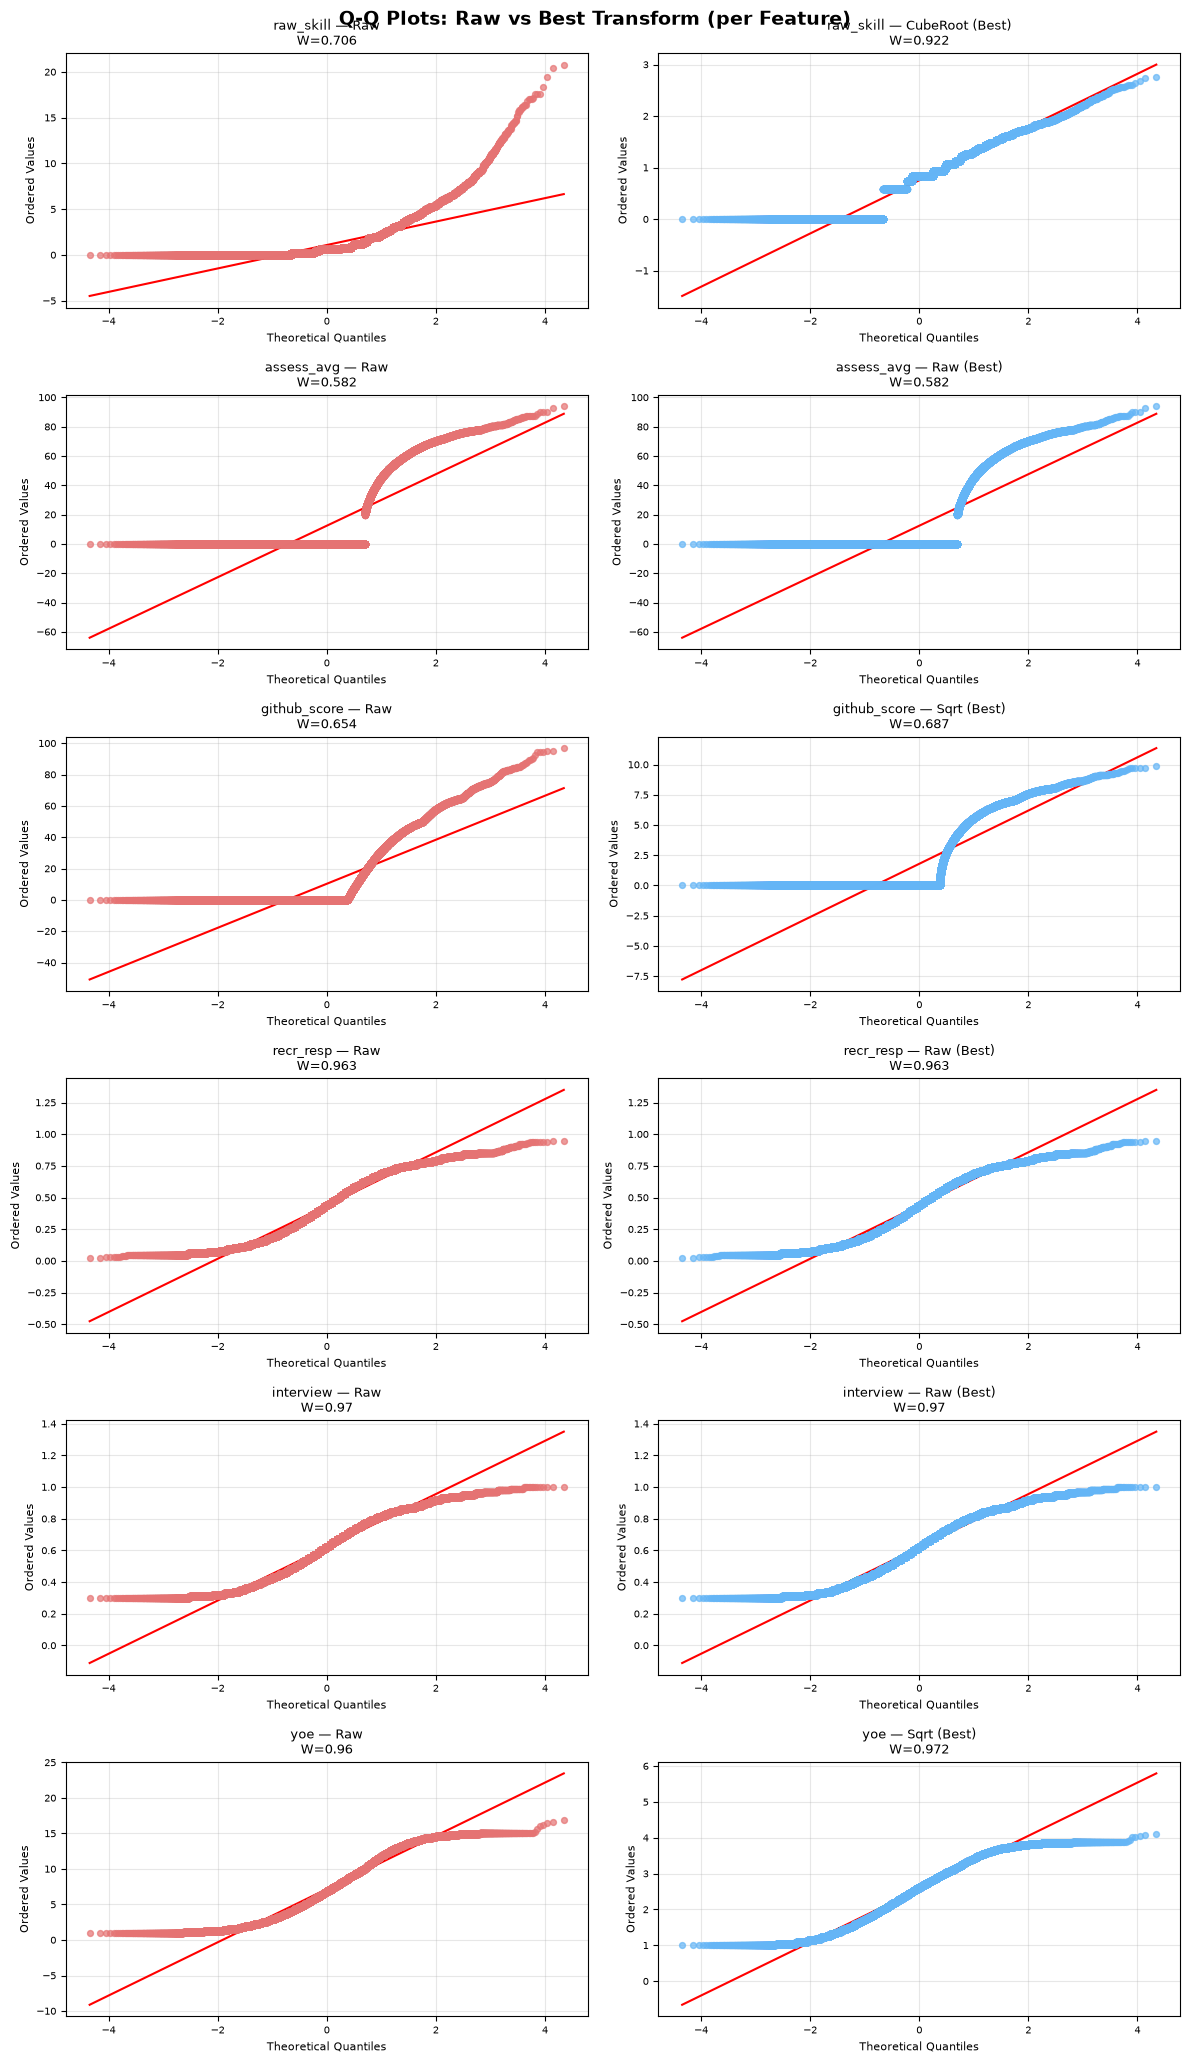

✅ Q-Q plots generated. Look for tighter fit to the red line on the RIGHT column.


In [14]:
df_transformed = df_raw[['candidate_id', 'current_title',
              'open_to_work',
              'days_inactive', 'suspicious_ratio']].copy()

# Apply the winning transform to each score feature
for feat in SCORE_FEATURES:
  winner_fn = TRANSFORMS[transform_winners[feat]]
  df_transformed[feat] = winner_fn(df_raw[feat]).values

# ── Q-Q Plot: Raw vs Best Transform, side by side ───────────────────────
fig, axes = plt.subplots(len(SCORE_FEATURES), 2,
             figsize=(12, 3.5 * len(SCORE_FEATURES)))
fig.suptitle('Q-Q Plots: Raw vs Best Transform (per Feature)',
       fontsize=14, fontweight='bold')

for i, feat in enumerate(SCORE_FEATURES):
  winner = transform_winners[feat]

  for j, (label, data) in enumerate([
    ('Raw', df_raw[feat]),
    (f'{winner} (Best)', df_transformed[feat])
  ]):
    ax = axes[i][j]
    clean = data.dropna()
    clean = clean[np.isfinite(clean)]

    (osm, osr), (slope, intercept, r) = scipy_stats.probplot(clean, dist='norm')
    ax.scatter(osm, osr, s=18, alpha=0.7,
          color='#e57373' if j == 0 else '#64b5f6', zorder=3)
    ax.plot([min(osm), max(osm)],
        [slope * min(osm) + intercept, slope * max(osm) + intercept],
        color='red', lw=1.5)
    ax.set_title(f'{feat} — {label}\nW={round(r**2, 3)}', fontsize=9)
    ax.set_xlabel('Theoretical Quantiles', fontsize=8)
    ax.set_ylabel('Ordered Values', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()
print(" Q-Q plots generated. Look for tighter fit to the red line on the RIGHT column.")

## Cell 5: STEP 3 — Z-Score Outlier Elimination

**Z-Score has exactly one job here**: flag candidates who are statistical anomalies
on the RED-FLAG features (`days_inactive`, `suspicious_ratio`).

**Why Z-Score is safe here**: We compute Z-scores on the full pool we have right now
and immediately use them to filter. We never store these Z parameters for future use.

In [15]:
# Compute Z-scores on the raw red-flag features
# (we do NOT transform these — we want to flag extremes in their natural units)
for feat in REDFLAG_FEATURES:
  df_transformed[f'z_{feat}'] = zscore(df_raw[feat], nan_policy='omit')

# A candidate is an outlier if they are > Z_THRESHOLD on ANY red-flag feature
df_transformed['is_outlier'] = (
  (df_transformed['z_days_inactive']  > Z_THRESHOLD) |
  (df_transformed['z_suspicious_ratio'] > Z_THRESHOLD)
)

# Report
outliers = df_transformed[df_transformed['is_outlier']]
print(f" Outliers removed : {len(outliers)}")
print(f" Survivors     : {len(df_transformed) - len(outliers)}")

if len(outliers) > 0:
  print("\nEliminated candidates:")
  print(outliers[['candidate_id', 'current_title',
          'days_inactive', 'z_days_inactive',
          'suspicious_ratio', 'z_suspicious_ratio']].to_string(index=False))

# Keep only survivors for final scoring
df_clean = df_transformed[~df_transformed['is_outlier']].copy().reset_index(drop=True)

🚫 Outliers removed  : 2779
✅ Survivors         : 97221

Eliminated candidates:
candidate_id                   current_title  days_inactive  z_days_inactive  suspicious_ratio  z_suspicious_ratio
CAND_0000074              Operations Manager            240         1.445845          0.133333            5.204226
CAND_0000133                Graphic Designer            156         0.184359          0.153846            6.037489
CAND_0000195                Business Analyst            219         1.130473          0.125000            4.865712
CAND_0000201               Marketing Manager             60        -1.257340          0.153846            6.037489
CAND_0000203              Operations Manager             72        -1.077127          0.166667            6.558278
CAND_0000211              Operations Manager            231         1.310686          0.125000            4.865712
CAND_0000220               Marketing Manager             52        -1.377481          0.111111            4.301524
C

## Cell 6: STEP 4 — Percentile Rank (All Features → [0, 1])

**What**: Convert every transformed score feature into its percentile rank
within the surviving pool.

**Why**: Even after Log/Sqrt/CubeRoot transforms, features are still in different
units. Percentile rank makes them all directly comparable — a 0.9 means
"better than 90% of surviving candidates" regardless of which feature it is.

**Note**: `open_to_work` is binary (0 or 1) so we use it directly, no ranking needed.

In [16]:
PCT_FEATURES = []  # will hold the percentile column names

for feat in SCORE_FEATURES:
  pct_col = f'pct_{feat}'
  # pct=True → rank as fraction of total. method='average' → ties get mean rank.
  df_clean[pct_col] = df_clean[feat].rank(pct=True, method='average')
  PCT_FEATURES.append(pct_col)

# open_to_work is already 0 or 1 — treat as a direct percentile-like score
df_clean['pct_open_to_work'] = df_clean['open_to_work']
PCT_FEATURES.append('pct_open_to_work')

print(" Percentile ranks computed. All values now in [0, 1]:")
print(df_clean[PCT_FEATURES].describe().round(4))

✅ Percentile ranks computed. All values now in [0, 1]:
       pct_raw_skill  pct_assess_avg  pct_github_score  pct_recr_resp  \
count     97221.0000      97221.0000        97221.0000     97221.0000   
mean          0.5000          0.5000            0.5000         0.5000   
std           0.2849          0.2169            0.2466         0.2887   
min           0.1308          0.3790            0.3233         0.0000   
25%           0.1308          0.3790            0.3233         0.2449   
50%           0.5303          0.3790            0.3233         0.5025   
75%           0.7303          0.3790            0.7499         0.7486   
max           1.0000          1.0000            1.0000         1.0000   

       pct_interview     pct_yoe  pct_open_to_work  
count     97221.0000  97221.0000        97221.0000  
mean          0.5000      0.5000            0.3539  
std           0.2886      0.2887            0.4782  
min           0.0029      0.0021            0.0000  
25%           0.2517  

## Cell 7: STEP 5 — Shannon Entropy → Dynamic Weights

**What**: Compute Shannon Entropy for each percentile rank feature.
Normalize to get weights that sum to 1.0.

**Entropy formula**:
$$H(X) = -\sum_{i} p_i \log_2(p_i)$$

**Intuition**: A feature where all candidates score similarly (low variance)
has low entropy → it is a poor discriminator → low weight.
A feature with a wide spread → high entropy → high weight.
The data decides. We decide nothing.

📊 Dynamically computed weights (from Shannon Entropy):

Feature                 Entropy H     Weight
--------------------------------------------
  yoe                      3.3213     0.2011
  recr_resp                3.3196     0.2010
  interview                3.3183     0.2009
  raw_skill                2.8279     0.1712
  github_score             1.6293     0.0987
  assess_avg               1.1596     0.0702
  open_to_work             0.9375     0.0568
--------------------------------------------
  TOTAL                   16.5134     1.0000


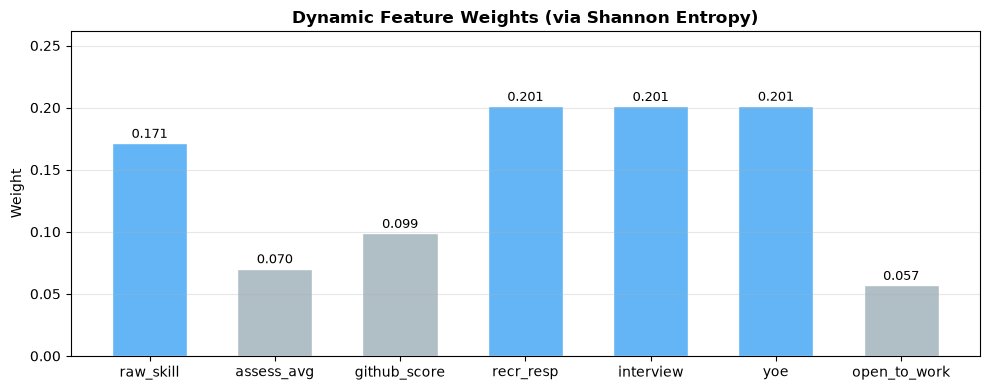

In [17]:
def shannon_entropy(series, bins=10):
  """
  Compute Shannon Entropy of a continuous feature.
  Higher = more spread = more discriminative = deserves more weight.
  """
  counts, _ = np.histogram(series.dropna(), bins=bins, range=(0, 1))
  probs = counts / counts.sum()     # convert to probability distribution
  probs = probs[probs > 0]       # remove zeros (log(0) undefined)
  return entropy(probs, base=2)     # H = -Σ p * log2(p)

# Compute raw entropy per feature
raw_entropies = {col: shannon_entropy(df_clean[col]) for col in PCT_FEATURES}

# Normalize: each weight = its entropy / sum of all entropies
total_h = sum(raw_entropies.values())
weights = {col: h / total_h for col, h in raw_entropies.items()}

# Print the dynamic weight table
print(" Dynamically computed weights (from Shannon Entropy):")
print(f"\n{'Feature':<22} {'Entropy H':>10} {'Weight':>10}")
print("-" * 44)
for col, w in sorted(weights.items(), key=lambda x: -x[1]):
  feat_label = col.replace('pct_', '')
  print(f" {feat_label:<20} {raw_entropies[col]:>10.4f} {w:>10.4f}")
print("-" * 44)
print(f" {'TOTAL':<20} {total_h:>10.4f} {sum(weights.values()):>10.4f}")

# Bar chart of weights
fig, ax = plt.subplots(figsize=(10, 4))
labels = [c.replace('pct_', '') for c in PCT_FEATURES]
vals  = [weights[c] for c in PCT_FEATURES]
colors = ['#64b5f6' if v >= max(vals) * 0.5 else '#b0bec5' for v in vals]
bars  = ax.bar(labels, vals, color=colors, edgecolor='white', width=0.6)
ax.set_title('Dynamic Feature Weights (via Shannon Entropy)', fontsize=12, fontweight='bold')
ax.set_ylabel('Weight')
ax.set_ylim(0, max(vals) * 1.3)
for bar, val in zip(bars, vals):
  ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
      f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 8: STEP 6 — Final Score (0–100)

**Formula**:
$$\text{Final Score} = \left(\sum_{i} w_i \times \text{pct\_rank}_i\right) \times 100$$

This is **guaranteed to be in [0, 100]** because:
- Each $w_i \in [0, 1]$ and $\sum w_i = 1$
- Each $\text{pct\_rank}_i \in [0, 1]$
- Therefore the sum is in $[0, 1]$ → multiply by 100 → $[0, 100]$

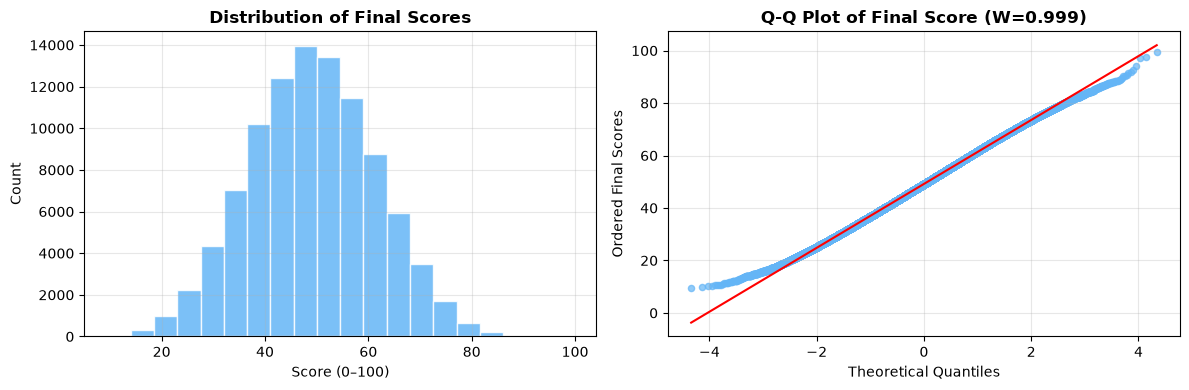


🏆 TOP 10 CANDIDATES:
 rank candidate_id                   current_title  final_score
    1 CAND_0039754        Senior Applied Scientist        99.60
    2 CAND_0095619                    NLP Engineer        97.39
    3 CAND_0055992                     AI Engineer        97.00
    4 CAND_0013536             Applied ML Engineer        94.25
    5 CAND_0088025 Staff Machine Learning Engineer        92.67
    6 CAND_0041874               Frontend Engineer        91.73
    7 CAND_0079821                     QA Engineer        91.53
    8 CAND_0041669 Recommendation Systems Engineer        90.74
    9 CAND_0064326                 Search Engineer        90.35
   10 CAND_0019783                  Civil Engineer        90.22


In [18]:
# Weighted sum of percentile ranks
df_clean['final_score'] = sum(
  weights[col] * df_clean[col] for col in PCT_FEATURES
) * 100

df_clean['final_score'] = df_clean['final_score'].round(2)
df_clean['rank']    = df_clean['final_score'].rank(
  ascending=False, method='min'
).astype(int)

df_final = df_clean.sort_values('final_score', ascending=False).reset_index(drop=True)

# ── Distribution of final scores ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_final['final_score'], bins=20,
       color='#64b5f6', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Final Scores', fontweight='bold')
axes[0].set_xlabel('Score (0–100)')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# Q-Q plot of the final score itself
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(
  df_final['final_score'], dist='norm')
axes[1].scatter(osm, osr, s=20, alpha=0.7, color='#64b5f6')
axes[1].plot([min(osm), max(osm)],
       [slope * min(osm) + intercept, slope * max(osm) + intercept],
       color='red', lw=1.5)
axes[1].set_title(f'Q-Q Plot of Final Score (W={r**2:.3f})', fontweight='bold')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Ordered Final Scores')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n TOP 10 CANDIDATES:")
print(df_final[['rank', 'candidate_id', 'current_title',
        'final_score']].head(10).to_string(index=False))

## Cell 9: Explainability — Why Did Each Candidate Score This Way?

The hackathon requires reasoning for the top 100. This cell generates
a human-readable explanation for every candidate based on which
features contributed most to their score.

In [19]:
def explain(row, top_n=3):
  """
  For a candidate row, find which percentile features contributed
  the most to their final score and generate a sentence.
  """
  contributions = {
    col: weights[col] * row[col]   # weighted contribution of each feature
    for col in PCT_FEATURES
  }
  # Sort by contribution descending
  top_features = sorted(contributions, key=contributions.get, reverse=True)[:top_n]

  feat_labels = {
    'pct_raw_skill'  : 'strong AI skill set',
    'pct_assess_avg'  : 'high platform assessment scores',
    'pct_github_score' : 'active GitHub presence',
    'pct_recr_resp'  : 'high recruiter response rate',
    'pct_interview'  : 'strong interview completion record',
    'pct_yoe'     : 'relevant years of experience',
    'pct_open_to_work' : 'active job-seeking status',
  }

  reasons = [feat_labels.get(f, f.replace('pct_','')) for f in top_features]
  return f"Ranked #{int(row['rank'])} due to: {', '.join(reasons)}."

# Generate explanations for top 10
print("\n Candidate Explanations (Top 10):")
print("=" * 70)
for _, row in df_final.head(10).iterrows():
  print(f" {row['candidate_id']} ({row['current_title']})")
  print(f" Score: {row['final_score']:.2f}/100")
  print(f" → {explain(row)}")
  print()


📝 Candidate Explanations (Top 10):
  CAND_0039754 (Senior Applied Scientist)
  Score: 99.60/100
  → Ranked #1 due to: relevant years of experience, strong interview completion record, high recruiter response rate.

  CAND_0095619 (NLP Engineer)
  Score: 97.39/100
  → Ranked #2 due to: relevant years of experience, high recruiter response rate, strong interview completion record.

  CAND_0055992 (AI Engineer)
  Score: 97.00/100
  → Ranked #3 due to: relevant years of experience, strong interview completion record, high recruiter response rate.

  CAND_0013536 (Applied ML Engineer)
  Score: 94.25/100
  → Ranked #4 due to: high recruiter response rate, relevant years of experience, strong AI skill set.

  CAND_0088025 (Staff Machine Learning Engineer)
  Score: 92.67/100
  → Ranked #5 due to: strong interview completion record, high recruiter response rate, strong AI skill set.

  CAND_0041874 (Frontend Engineer)
  Score: 91.73/100
  → Ranked #6 due to: high recruiter response rate, stron

## Cell 10: Export — submission-ready CSV

Save the top 100 with rankings and reasoning. This is the format required for submission.

In [20]:
# Generate explanations for ALL surviving candidates
df_final['reason'] = df_final.apply(explain, axis=1)

# Export top 100
top100 = df_final[['rank', 'candidate_id', 'final_score', 'reason']].head(100)
top100.to_csv('submission.csv', index=False)

print(" submission.csv saved with top 100 candidates.")
print(f"  Columns: {list(top100.columns)}")
print(f"  Rows  : {len(top100)}")
print("\nPreview:")
print(top100.head(5).to_string(index=False))

✅ submission.csv saved with top 100 candidates.
   Columns: ['rank', 'candidate_id', 'final_score', 'reason']
   Rows   : 100

Preview:
 rank candidate_id  final_score                                                                                                            reason
    1 CAND_0039754        99.60 Ranked #1 due to: relevant years of experience, strong interview completion record, high recruiter response rate.
    2 CAND_0095619        97.39 Ranked #2 due to: relevant years of experience, high recruiter response rate, strong interview completion record.
    3 CAND_0055992        97.00 Ranked #3 due to: relevant years of experience, strong interview completion record, high recruiter response rate.
    4 CAND_0013536        94.25                Ranked #4 due to: high recruiter response rate, relevant years of experience, strong AI skill set.
    5 CAND_0088025        92.67          Ranked #5 due to: strong interview completion record, high recruiter response rate, strong AI